# NAT/BUFR to GeoParquet

This notebook demonstrates how to convert EUMETSAT BUFR data to GeoParquet, compares access performance between BUFR and GeoParquet, and shows some basic geospatial capabilities of GeoParquet.

Steps:
- download/access the data
- convert the data to GeoParquet
- compare data access (partial reads)
- show simple geospatial capabilities of GeoParquet

First, we import the required packages.

In [1]:
import pdbufr
import shapely
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from satpy.scene import Scene

Next, we set up the local input and output directories, and point to the sample EUMETSAT MTG FCI L2 ASR BUFR file used throughout this notebook.

In [2]:
bufr_dirpath = Path('../data/04_asr_bufr')
geoparq_dirpath = Path('../outputs/04_asr_bufr')

bufr_dirpath.mkdir(parents=True, exist_ok=True)
geoparq_dirpath.mkdir(parents=True, exist_ok=True)

filename = "W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-ASR--FD------BUFR_C_EUMT_20260714142512_L2PF_OPE_20260714141000_20260714142000_N__O_0086_0000.bin"

## Conversion

Now we read the BUFR file using `pdbufr`'s flat reader, which parses it into a single flat table. This exposes every BUFR key as a column (most of which are not relevant here) and takes a while to run.

In [3]:
df = pdbufr.read_bufr(bufr_dirpath / filename, reader='flat')
df

,edition,masterTableNumber,bufrHeaderCentre,bufrHeaderSubCentre,updateSequenceNumber,dataCategory,internationalDataSubCategory,dataSubCategory,masterTablesVersionNumber,localTablesVersionNumber,...,#123#brightnessTemperature,#124#brightnessTemperature,#125#brightnessTemperature,#126#brightnessTemperature,#127#brightnessTemperature,#128#brightnessTemperature,#129#brightnessTemperature,#130#brightnessTemperature,#131#brightnessTemperature,#132#brightnessTemperature
0,4,0,254,0,0,5,255,41,16,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4,0,254,0,0,5,255,41,16,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,0,254,0,0,5,255,41,16,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,0,254,0,0,5,255,41,16,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0,254,0,0,5,255,41,16,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87889,4,0,254,0,0,5,255,41,16,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87890,4,0,254,0,0,5,255,41,16,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87891,4,0,254,0,0,5,255,41,16,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87892,4,0,254,0,0,5,255,41,16,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


To convert the table to GeoParquet, we first need to identify its geometry columns. The relevant BUFR keys turn out to be `#1#latitude` and `#1#longitude`, which we combine into point geometries before writing the result out as a GeoParquet file.

In [4]:
coords = shapely.points(np.stack([df['#1#latitude'], df['#1#longitude']], axis=-1))
gdf = gpd.GeoDataFrame(df, geometry=coords, crs="EPSG:4326")
geoparq_filename = "EUMETSAT_MTG_FCI_L2_ASR.parquet"
gdf.to_parquet(geoparq_dirpath / geoparq_filename)

## Benchmark

Benefit of working with Parquet:
- smaller file size, even though BUFR data is binary
- much faster opening times

While GeoParquet does not yet support spatial range requests, it's possible to load specific columns and (theoretically) row groups for even faster access.

Below we compare loading times between the GeoParquet file and the original BUFR file.

In [5]:
print('Loading GeoParquet')
%time _ = gpd.read_parquet(geoparq_dirpath / geoparq_filename)

print('Loading native BUFR file')
%time _ = pdbufr.read_bufr(bufr_dirpath / filename, reader='flat')

Loading GeoParquet
CPU times: user 519 ms, sys: 888 ms, total: 1.41 s
Wall time: 438 ms
Loading native BUFR file
CPU times: user 4min 3s, sys: 14.3 s, total: 4min 17s
Wall time: 4min 20s


## Visualisation

Finally, BUFR data can also be loaded via `satpy` as an `xarray.DataArray` for plotting or further processing (see the [MTG FCI L2 ASR data guide](https://user.eumetsat.int/resources/user-guides/mtg-fci-l2-asr-data-guide#ID-BUFR-libraries-and-tools)). Here we load the mean clear-sky brightness temperature for the IR10.5 channel and plot it on its native projection.

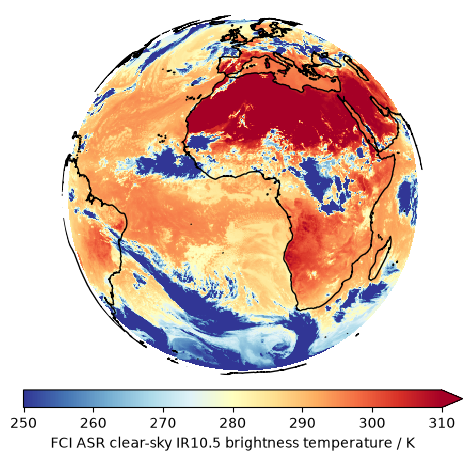

In [6]:
filepaths = [str(bufr_dirpath / filename)]

scn = Scene(
    filenames=filepaths,
    reader="fci_l2_bufr",
    reader_kwargs={"with_area_definition": True},
)

dataset = "bt_mean_all_ir105"  # Dataset to load – average clear-sky brightness temperature for IR10.5 channel
# Load dataset. The upper_right_corner keyword is needed to flip the dataset to "human" projection
scn.load([dataset], upper_right_corner='NE')

# Extract dataset from Scene object
xarr = scn[dataset] # daskified xarray.DataArray with the FCI ASR bt_mean_clear_ir105 dataset

# Extract area definition with information about projection, dataset shape and area extent
adef = xarr.attrs['area']  # Pyresample AreaDefinition object

# Compute the center longitudes and latitudes of the cloud_state dataset grid
lons, lats = adef.get_lonlats()  # 2D arrays with pixel centre longitude and latitude
crs = adef.to_cartopy_crs()  # Convert area definition to cartopy CRS object

fig, ax = plt.subplots(subplot_kw={'projection': crs})
ax.coastlines(resolution='50m')
im = ax.imshow(xarr.values, transform=crs, cmap='RdYlBu_r', extent=crs.bounds, origin='upper', vmin=250, vmax=310, interpolation='none')
plt.axis('off')
cbar = plt.colorbar(im, orientation='horizontal', extend='max', aspect=25, shrink=0.72, pad=0.02)
cbar.ax.set_xlabel('FCI ASR clear-sky IR10.5 brightness temperature / K')
plt.tight_layout()
plt.show()